# Batch Normalization

## Start with the problem: intermediate values change during training

As earlier layers learn, the values entering a later layer can change scale. Optimization can become sensitive to initialization and learning rate. Batch normalization (BatchNorm) uses per-feature or per-channel statistics to normalize intermediate values, then supplies a learned scale and shift so the network can choose useful output ranges.

BatchNorm is part of the network's computation, not a preprocessing scaler fitted once to the raw dataset. Its behavior depends on training or evaluation mode and on the dimensions over which statistics are calculated. It often helps optimization, but it is not required for every architecture and is not guaranteed to improve generalization.

This lesson works through a complete forward calculation, backward derivatives, running statistics, and inference. All examples use local tensors on CPU. They verify mechanisms rather than claim that adding BatchNorm improves a trained classifier.

Run the [code companion](16_Batch_Normalization.ipynb). Read this lesson after [CNN Components](15_CNN_Components_Notes.ipynb); [Regularization in Deep Learning](11_Regularization_in_Deep_Learning_Notes.ipynb) explains the separate goal of controlling overfitting.

## See the two BatchNorm paths

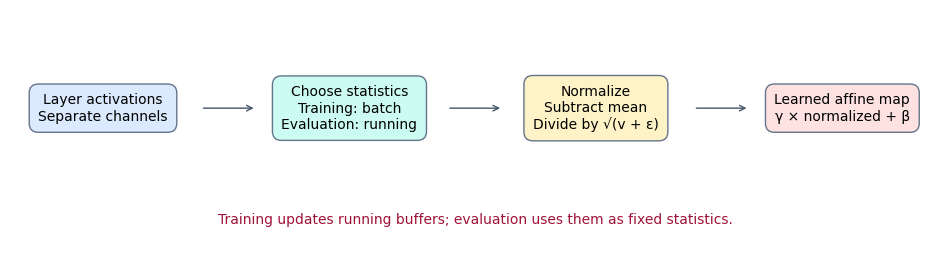

Training updates running buffers; evaluation uses them as fixed statistics.

## Calculate one channel's mean, variance, scale, and shift

Take one channel with values $[1,3,5,7]$. Let $M=4$ be the number of values used in its training statistics. The mean is $\mu=(1+3+5+7)/4=4$. Deviations are $[-3,-1,1,3]$ and squared deviations are $[9,1,1,9]$.

The variance used in the training forward pass is the population-style estimate $v=(9+1+1+9)/4=5$. BatchNorm calculates

$$\hat x_i=\frac{x_i-\mu}{\sqrt{v+\epsilon}},\qquad y_i=\gamma\hat x_i+\beta.$$

With $\epsilon=10^{-5}$, the denominator is approximately $2.236070$. Normalized values are approximately $[-1.341639,-0.447213,0.447213,1.341639]$. Set learned scale $\gamma=2$ and shift $\beta=0.5$. Outputs become approximately $[-2.183279,-0.394426,1.394426,3.183279]$.

The normalized mean is zero and its variance is $v/(v+\epsilon)$, slightly below one. Epsilon prevents division by zero and affects exact scale invariance. Gamma and beta are trainable parameters, one pair per channel. They allow the following layer to receive a useful range rather than forcing every channel permanently to zero mean and unit variance.

The batch mean and variance are computed from activations; they are not independent parameters updated by an optimizer. The network still needs its task loss to teach the affine parameters and the layers around BatchNorm.

## See normalization and learned rescaling

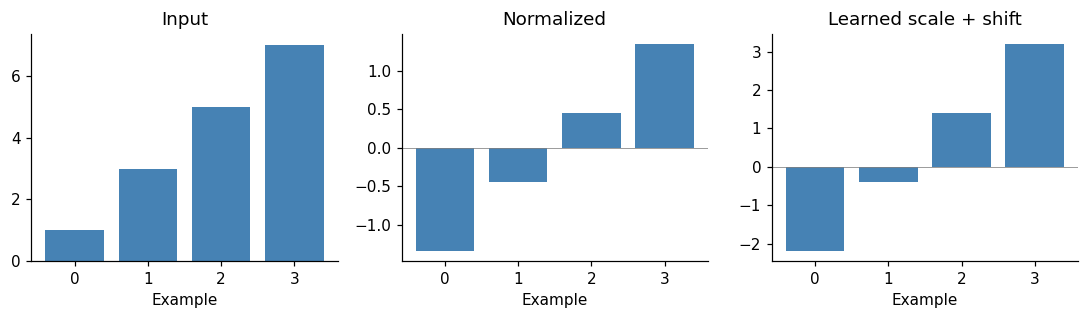

A channel is centered and scaled, then transformed by its learned gamma and beta. The affine result need not have mean zero or variance one.

## Learn which axes share statistics

For input `(N, C)`, `BatchNorm1d(C)` computes statistics down the batch axis separately for each feature. For `(N, C, L)` it combines the batch and length axes. `BatchNorm2d(C)` expects `(N, C, H, W)` and combines $N,H,W$ separately for each channel.

For one image with two channels $[[1,3],[5,7]]$ and $[[10,12],[14,16]]$, channel means are four and thirteen; both training variances are five. The normalized spatial patterns are therefore equal. BatchNorm does not mix the channels to find one grand mean.

Even an image batch of size one can have several values per channel because spatial positions also contribute. Conversely, training on shape `(1,C)` has only one value per feature and standard PyTorch BatchNorm cannot compute its required training statistics. Effective sample count and the correlations between spatial positions matter; “batch size one” alone is not a complete description.

## Trace gradients through the normalization calculation

Normalization couples the values in a channel: changing one changes the mean and variance used for the others. Treating these statistics as fixed constants during training gives the wrong backward result.

Suppose an upstream computation sends derivatives $g=\partial L/\partial y=[1,2,0,-1]$ into our four-value example. To reproduce exactly this teaching signal, the code uses scalar $L=\sum_i g_i y_i$. This is a local derivative illustration, not a useful standalone learning objective.

The affine gradients are

$$\frac{\partial L}{\partial\beta}=\sum_i g_i=2,\qquad
\frac{\partial L}{\partial\gamma}=\sum_i g_i\hat x_i\approx-3.577705.$$

For example, the gamma contributions are approximately $1(-1.341639)+2(-0.447213)+0(0.447213)+(-1)(1.341639)$.

Let $s=\sqrt{v+\epsilon}$. The input derivative for each value is

$$\frac{\partial L}{\partial x_i}=\frac{\gamma}{Ms}\left(Mg_i-\sum_jg_j-\hat x_i\sum_j g_j\hat x_j\right).$$

This includes both the mean and variance dependence. Substituting the values gives approximately $[-0.626096,0.983870,-0.089443,-0.268330]$. The derivatives sum to zero: shifting all four inputs together does not alter their centered differences.

If an optimizer applied rate $0.1$ to the affine parameters alone, beta would become $0.5-0.1(2)=0.3$ and gamma would become approximately $2-0.1(-3.577705)=2.357771$. In an ANN, the input derivatives also continue into the preceding layer's weights. This is how normalization participates in learning rather than merely formatting numbers.

## Running statistics explain why evaluation differs

Default BatchNorm tracks running mean and variance as buffers. With numeric momentum $m$, the update is `running ← (1-m) × running + m × current_statistic`. This momentum controls an exponential average; it is unrelated to optimizer momentum.

There is a deliberate estimator distinction in PyTorch: the training forward pass above divides squared deviations by $M=4$, giving variance five, while the running-variance update uses the unbiased estimate dividing by $M-1=3$, giving $20/3\approx6.666667$.

We used momentum one, so after that batch running mean is four and running variance is $20/3$. In evaluation, the same input is computed as $2(x-4)/\sqrt{20/3+10^{-5}}+0.5$, giving approximately $[-1.823788,-0.274596,1.274596,2.823788]$. It need not equal the training output from that same batch.

With momentum 0.1 and initial buffers mean zero, variance one, one batch would instead produce running mean $0.9(0)+0.1(4)=0.4$ and running variance $0.9(1)+0.1(20/3)=1.566667$. A single update is not a reliable estimate of a whole activation distribution. Representative training batches and the chosen averaging behavior matter.

Evaluation normally uses these stored statistics so a prediction does not depend on whatever other examples happen to arrive beside it. If `track_running_stats=False`, batch statistics are used even in evaluation; this changes the inference contract.

## Keep mode changes, gradient tracking, and freezing separate

`train()` or `eval()` selects layer behavior. `torch.no_grad()` controls graph recording. Setting `requires_grad=False` prevents parameter gradients. These are three different choices.

A training-mode BatchNorm still updates its running buffers inside `no_grad()`. Freezing gamma and beta also does not freeze the buffers. During transfer learning, a supposedly frozen backbone with BatchNorm can therefore change its predictions if left in training mode. Use the appropriate evaluation behavior when the entire pretrained computation must remain fixed.

Conversely, evaluation mode does not automatically disable gradients. One can compute gradients through evaluation-mode BatchNorm using its fixed statistics. For ordinary inference, use both `eval()` and a no-gradient context. The code checks each distinction explicitly, because silently conflating them is a common source of inconsistent predictions.

## Show why batch composition matters and compare LayerNorm

With BatchNorm, an example's training output can depend on the other values used in its channel statistics. A value one alongside three has mean two and standard deviation near one, so its normalized output is near minus one. The same value alongside seven and nine belongs to a batch with mean approximately 5.667 and variance approximately 11.556, giving a different normalized response.

In evaluation with tracked statistics fixed, that same input value receives the same result regardless of the other examples in the batch. A channel's stored statistics must be appropriate for the data distribution; evaluation mode cannot repair a distribution shift by itself.

LayerNorm normalizes selected feature dimensions within each example rather than using the batch. For rows `[[1,3],[5,7]]`, LayerNorm over two features gives approximately `[[-1,1],[-1,1]]`. BatchNorm over its two feature columns instead gives approximately `[[-1,-1],[1,1]]`. These are different operations with different assumptions. Neither is a universally better replacement for the other.

## Fold a trained evaluation-mode normalization into a convolution

A common CNN block is convolution → BatchNorm → activation. During training, the per-channel mean cancels a preceding convolution bias, so that bias is often omitted when BatchNorm already has a learned shift. This is an architectural convenience, not a requirement of the formula.

At evaluation, the stored statistics are constants. For one output channel with convolution $u=Wx+b$, BatchNorm computes

$$y=\frac{\gamma}{\sqrt{v_{run}+\epsilon}}(Wx+b-\mu_{run})+\beta.$$

Let $a=\gamma/\sqrt{v_{run}+\epsilon}$. Define $W'=aW$ and $b'=a(b-\mu_{run})+\beta$. Then $W'x+b'$ gives the same evaluation result. Each output channel has its own scale $a$.

The code constructs a Conv–BatchNorm pair, populates statistics with a demonstration batch, switches to evaluation, and verifies the folded convolution. This equality applies to fixed evaluation statistics, not training mode where statistics depend on the current inputs. The populated demo buffers are not a claim of trained model quality.

## Save the buffers as well as the learned parameters

A BatchNorm state includes gamma and beta, running mean and variance, and a counter of batches tracked. The running values are buffers, not optimizer parameters, but they affect inference. Copying only learned parameters loses part of the prediction recipe.

Save and reload `state_dict` with the architecture and normalization settings. Evaluation mode is not restored merely by loading a state dictionary into a new module, so call `eval()` explicitly. The example round-trips a small block in a temporary checkpoint and verifies identical evaluation outputs. No checkpoint remains after the demonstration.

BatchNorm can help optimize a network and can introduce training noise through batch statistics, sometimes with a regularizing effect. It is not a guarantee against overfitting. Representative batches, appropriate normalization axes, correct evaluation behavior, and held-out comparisons remain necessary.

## Read the verified calculations

All 9 code cells and embedded assertions passed in a fresh in-process CPU kernel. Manual mean, variance, affine output, gamma/beta gradients, and all input gradients matched PyTorch. Checks confirmed the different training-forward and running-variance estimators, correct channel axes, dependence on training-batch composition, and fixed-statistic evaluation behavior.

Freezing affine parameters and disabling gradient recording did not stop training-mode buffer updates; evaluation mode did. Folding Conv–BatchNorm into a convolution matched evaluation outputs to floating-point precision (maximum discrepancy 8.88e-16). Saving and restoring all parameters and buffers reproduced the same predictions. These checks explain the layer's behavior; they do not claim a trained-model accuracy improvement.